# GBS v2 - Evento: Declínio Estrutural
## Case Declínio de SKU - Grupo Boticário

**Evento:** Expansão fraca + retração PDVs por 5 ciclos

**Features:** Selecionadas por significância estatística (Kruskal-Wallis) + insights EDA

**Previsão:** P(declinar próx 25 ciclos | vivo hoje) = 1 - S(t+25)/S(t)

**Autor:** Gustavo

---
## 1. Setup

In [1]:
!pip install scikit-survival -q

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.inspection import permutation_importance

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.nonparametric import kaplan_meier_estimator

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

FIGURES_DIR = '/content/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
HORIZONTE = 25
print('Bibliotecas carregadas!')

Bibliotecas carregadas!


---
## 2. Dados

In [5]:
from google.colab import drive
drive.mount('/content/drive')
#
# # Ajuste o caminho abaixo conforme a localização do arquivo no seu Drive
filepath = "/content/drive/MyDrive/Case SKU/data/base-de-dados.csv"
df = pd.read_csv(filepath, thousands=".")
print(f"Dados carregados com sucesso: {df.shape[0]} linhas x {df.shape[1]} colunas")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dados carregados com sucesso: 126781 linhas x 22 colunas


In [18]:
cols_object = df.select_dtypes(include=['object']).columns.tolist()
cols_excluir = ['sk_produto_case','cod_canal_portfolio','des_categoria_portfolio','des_status_atual_agrup']
for col in cols_object:
    if col not in cols_excluir:
        amostra = df[col].dropna().head(100).astype(str)
        if amostra.str.match(r'^[\d\s\.\,\-\+R\$%]+$').mean() > 0.7:
            serie = df[col].astype(str).str.strip().str.replace('.','',regex=False).str.replace(',','.',regex=False)
            df[col] = pd.to_numeric(serie, errors='coerce')
print('Tratamento concluído!')
print(df.dtypes.value_counts())

Tratamento concluído!
int64      15
float64     9
object      4
bool        1
Name: count, dtype: int64


In [37]:
df[['cod_phase_in_agrup', 'cod_phase_out_agrup']]

KeyError: ('cod_phase_in_agrup', 'cod_phase_out_agrup')

---
## 3. Evento: Declínio Estrutural

In [20]:
# ============================================================
# DEFINIÇÃO DO EVENTO: DECLÍNIO BOTICÁRIO (v3)
# Combina: perda de lojas + exaustão de novos PDVs + queda de receita
# Confirmação por janela de 5 ciclos (evita ruído sazonal)
# ============================================================

ciclos_ordenados = sorted(df['cod_ciclo'].unique())
mapa_ciclo = {ciclo: idx for idx, ciclo in enumerate(ciclos_ordenados)}
df['ordem_ciclo'] = df['cod_ciclo'].map(mapa_ciclo)

def definir_evento_declinio_boticario(df, janela_confirmacao=4):
    """
    Define o evento binário de declínio baseado em perda de capilaridade e tração.
    """
    df = df.sort_values(['sk_produto_case', 'cod_ciclo'])

    group = df.groupby('sk_produto_case')

    # Tendência da Base Total de PDVs (H: 16547.35)
    df['slope_cpfs_total'] = group['ind_cpfs_total'].diff()

    # Exaustão de Novos PDVs (sinal precoce a -80 ciclos)
    df['mediana_hist_novos'] = group['ind_cpfs_novos'].transform('median')
    df['expansao_abaixo_mediana'] = df['ind_cpfs_novos'] < df['mediana_hist_novos']

    # Lógica de Declínio: perda de lojas + sem novos + receita caindo
    df['sinal_declinio'] = (
        (df['slope_cpfs_total'] < 0) &
        (df['expansao_abaixo_mediana']) &
        (df['ind_vlr_receita_real_dia_corrigido'] < group['ind_vlr_receita_real_dia_corrigido'].shift(1))
    ).astype(int)

    # Filtro de Robustez (janela de confirmação)
    df['evento_declinio'] = group['sinal_declinio'].transform(
        lambda x: x.rolling(window=janela_confirmacao).sum() >= (janela_confirmacao - 1)
    ).astype(int)

    return df

df = definir_evento_declinio_boticario(df, janela_confirmacao=4)

# Calcular tempo até o evento
def calc_tempo(grupo):
    primeiro = grupo['ordem_ciclo'].min()
    eventos = grupo[grupo['evento_declinio'] == 1]['ordem_ciclo']
    if len(eventos) > 0:
        return pd.Series({'duracao': max(eventos.min() - primeiro + 1, 1), 'evento': True})
    return pd.Series({'duracao': max(grupo['ordem_ciclo'].max() - primeiro + 1, 1), 'evento': False})

vida_produto = df.groupby('sk_produto_case').apply(calc_tempo).reset_index()
vida_produto['evento'] = vida_produto['evento'].astype(bool)
vida_produto['duracao'] = vida_produto['duracao'].astype(float)

print(f'{"="*60}')
print(f'EVENTO: DECLÍNIO BOTICÁRIO (v3)')
print(f'Critérios: Perdendo lojas + Sem novos PDVs + Receita caindo')
print(f'Confirmação: {5} ciclos consecutivos')
print(f'{"="*60}')
print(f'Total de produtos: {len(vida_produto)}')
print(f'Com declínio: {vida_produto["evento"].sum()} ({vida_produto["evento"].mean()*100:.1f}%)')
print(f'Censurados: {(~vida_produto["evento"]).sum()} ({(~vida_produto["evento"]).mean()*100:.1f}%)')
print(f'Duração média até evento: {vida_produto[vida_produto["evento"]]["duracao"].mean():.1f} ciclos')


EVENTO: DECLÍNIO BOTICÁRIO (v3)
Critérios: Perdendo lojas + Sem novos PDVs + Receita caindo
Confirmação: 5 ciclos consecutivos
Total de produtos: 2462
Com declínio: 1417 (57.6%)
Censurados: 1045 (42.4%)
Duração média até evento: 39.3 ciclos


---
## 4. Feature Engineering v2

In [22]:
# ============================================================
# FEATURE ENGINEERING v3 - OTIMIZADO (~15 features)
# Sem leakage, sem ruído, foco em capilaridade + receita + slopes
# ============================================================

vars_base = [
    'ind_cpfs_novos',
    'ind_cpfs_total',
    'ind_vlr_receita_real_dia_corrigido',
    'ind_vlr_receita_real_corrigido',
    'ind_vlr_ruptura',
    'ind_qtd_ciclos_agrupador',
]
vars_base = [v for v in vars_base if v in df.columns]

df_sorted = df.sort_values(['sk_produto_case', 'ordem_ciclo'])

# Colunas derivadas ANTES dos subsets
df_sorted['flag_ruptura'] = (df_sorted['ind_vlr_ruptura'] > 0).astype(int)
df_sorted['receita_por_cpf'] = (
    df_sorted['ind_vlr_receita_real_dia_corrigido'] /
    df_sorted['ind_cpfs_total'].replace(0, np.nan)
)

# Subsets
df_ultimos5 = df_sorted.groupby('sk_produto_case').tail(5)
df_ultimos10 = df_sorted.groupby('sk_produto_case').tail(10)

# SLOPES
def calc_slope(g, v):
    x = np.arange(len(g)); y = g[v].values
    mask = ~np.isnan(y)
    if mask.sum() >= 3: return stats.linregress(x[mask], y[mask])[0]
    return 0

vars_slope = ['ind_cpfs_novos', 'ind_cpfs_total', 'ind_vlr_receita_real_dia_corrigido', 'ind_vlr_ruptura']
vars_slope = [v for v in vars_slope if v in df.columns]

slopes_5 = {}
for var in vars_slope:
    slopes_5[f'{var}_slope_ult5'] = df_ultimos5.groupby('sk_produto_case').apply(lambda g, v=var: calc_slope(g, v))
feat_slope_5 = pd.DataFrame(slopes_5)

slopes_10 = {}
for var in vars_slope:
    slopes_10[f'{var}_slope_ult10'] = df_ultimos10.groupby('sk_produto_case').apply(lambda g, v=var: calc_slope(g, v))
feat_slope_10 = pd.DataFrame(slopes_10)

# MÉDIAS
feat_media = df_sorted.groupby('sk_produto_case')[vars_base].mean()
feat_media.columns = [f'{c}_media' for c in feat_media.columns]

# TICKET MÉDIO
feat_ticket = df_sorted.groupby('sk_produto_case')['receita_por_cpf'].mean().reset_index(name='ticket_medio_media')
feat_ticket_slope = df_sorted.groupby('sk_produto_case').apply(
    lambda g: calc_slope(g, 'receita_por_cpf')
).rename('ticket_medio_slope').reset_index()

# RUPTURA
ruptura_ult10 = df_ultimos10.groupby('sk_produto_case')['flag_ruptura'].mean().reset_index(name='prop_ruptura_ult10')
ruptura_global = df_sorted.groupby('sk_produto_case')['flag_ruptura'].mean().reset_index(name='prop_ruptura')

# IDADE (apenas phase_in, sem phase_out = sem leakage)
feat_idade = pd.DataFrame({'sk_produto_case': df['sk_produto_case'].unique()})
if 'cod_phase_in_agrup' in df.columns:
    df['ordem_phase_in'] = df['cod_phase_in_agrup'].map(mapa_ciclo)
    pi = df.groupby('sk_produto_case')['ordem_phase_in'].first().reset_index()
    ult = df.groupby('sk_produto_case')['ordem_ciclo'].max().reset_index(name='ult_obs')
    feat_idade = feat_idade.merge(pi, on='sk_produto_case', how='left')
    feat_idade = feat_idade.merge(ult, on='sk_produto_case', how='left')
    feat_idade['idade_produto'] = feat_idade['ult_obs'] - feat_idade['ordem_phase_in']
    feat_idade = feat_idade.drop(columns=['ordem_phase_in', 'ult_obs'], errors='ignore')

print('Feature Engineering v3 concluído!')
print(f'Removidos (leakage/ruído):')
print('  ✗ flag_tem_phase_out, vida_planejada')
print('  ✗ vlr_investimento_mkt_direto (p=0.45)')
print('  ✗ tx_conversao_pdv (p=0.62)')
print('  ✗ repacking, baseline redundante')


Feature Engineering v3 concluído!
Removidos (leakage/ruído):
  ✗ flag_tem_phase_out, vida_planejada
  ✗ vlr_investimento_mkt_direto (p=0.45)
  ✗ tx_conversao_pdv (p=0.62)
  ✗ repacking, baseline redundante


---
## 5. Dataset Final

In [23]:
# ============================================================
# MONTAGEM DO DATASET v3
# ============================================================

df_surv = vida_produto[['sk_produto_case', 'duracao', 'evento']].copy()
df_surv = df_surv.merge(feat_media.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_slope_5.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_slope_10.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_ticket, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_ticket_slope, on='sk_produto_case', how='left')
df_surv = df_surv.merge(ruptura_ult10, on='sk_produto_case', how='left')
df_surv = df_surv.merge(ruptura_global, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_idade, on='sk_produto_case', how='left')

feature_cols = [c for c in df_surv.columns if c not in ['sk_produto_case', 'duracao', 'evento']]
df_surv[feature_cols] = df_surv[feature_cols].replace([np.inf, -np.inf], np.nan)
df_surv[feature_cols] = df_surv[feature_cols].fillna(df_surv[feature_cols].median())

print(f'Dataset: {len(df_surv)} produtos | {len(feature_cols)} features')
print(f'Features ({len(feature_cols)}):')
for f in sorted(feature_cols):
    print(f'  - {f}')


Dataset: 2462 produtos | 19 features
Features (19):
  - idade_produto
  - ind_cpfs_novos_media
  - ind_cpfs_novos_slope_ult10
  - ind_cpfs_novos_slope_ult5
  - ind_cpfs_total_media
  - ind_cpfs_total_slope_ult10
  - ind_cpfs_total_slope_ult5
  - ind_qtd_ciclos_agrupador_media
  - ind_vlr_receita_real_corrigido_media
  - ind_vlr_receita_real_dia_corrigido_media
  - ind_vlr_receita_real_dia_corrigido_slope_ult10
  - ind_vlr_receita_real_dia_corrigido_slope_ult5
  - ind_vlr_ruptura_media
  - ind_vlr_ruptura_slope_ult10
  - ind_vlr_ruptura_slope_ult5
  - prop_ruptura
  - prop_ruptura_ult10
  - ticket_medio_media
  - ticket_medio_slope


---
## 6. Split

---
## 7. Treinamento

In [24]:
# ============================================================
# SPLIT + TREINO + AVALIAÇÃO
# ============================================================

X = df_surv[feature_cols].values
y = np.array([(e, d) for e, d in zip(df_surv['evento'], df_surv['duracao'])], dtype=[('evento', bool), ('duracao', float)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=df_surv['evento'].astype(int))
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Treino: {len(X_train)} ({y_train["evento"].sum()} eventos)')
print(f'Teste:  {len(X_test)} ({y_test["evento"].sum()} eventos)')

# Treinar
gbs = GradientBoostingSurvivalAnalysis(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    min_samples_split=10, min_samples_leaf=5,
    subsample=0.8, max_features='sqrt',
    dropout_rate=0.1, random_state=42, verbose=1,
)
print('Treinando...')
gbs.fit(X_train_s, y_train)

c_train = gbs.score(X_train_s, y_train)
c_test = gbs.score(X_test_s, y_test)
print(f'C-Index Treino: {c_train:.4f}')
print(f'C-Index Teste:  {c_test:.4f}')
print(f'Gap: {c_train - c_test:.4f} (menor = menos overfitting)')
print(f'{"BOM" if c_test >= 0.65 else "PRECISA AJUSTAR"}: 0.5=random | 0.7=bom | 0.8=excelente')


Treino: 1846 (1062 eventos)
Teste:  616 (355 eventos)
Treinando...
      Iter       Train Loss      OOB Improve   Remaining Time 
         1        5260.5710           0.0000           17.75s
         2        5099.9319        -123.9137           17.71s
         3        5127.8169          22.2341           17.62s
         4        5164.2063          29.7147           17.64s
         5        5089.4338         -57.5026           17.82s
         6        5186.0674          78.5871           17.74s
         7        5119.7352         -52.6755           17.98s
         8        5104.9060         -13.6117           17.91s
         9        5079.1811         -17.3061           17.86s
        10        5173.6052          75.9699           17.82s
        20        5130.6067         -36.8750           17.33s
        30        5180.5844           9.3474           17.05s
        40        5218.3396          56.5596           16.69s
        50        5094.0161         -61.2639           16.24s
  

In [25]:
# ============================================================
# PREVISÃO CONDICIONAL: Próximos 25 ciclos
# P(T < t+25 | T > t) = 1 - S(t+25) / S(t)
# ============================================================

df_vivos = df_surv[df_surv['evento'] == False].copy()
print(f'Prevendo para {len(df_vivos)} produtos SEM evento')

X_vivos = df_vivos[feature_cols].values
X_vivos_s = scaler.transform(X_vivos)
surv_vivos = gbs.predict_survival_function(X_vivos_s)
risk_vivos = gbs.predict(X_vivos_s)

prob_proximos_25 = []
ciclo_declinio_list = []

for i, fn in enumerate(surv_vivos):
    t_atual = df_vivos.iloc[i]['duracao']
    t_futuro = t_atual + HORIZONTE
    s_atual = fn(min(t_atual, fn.x.max()))
    s_futuro = fn(min(t_futuro, fn.x.max()))
    prob_cond = np.clip(1 - (s_futuro / s_atual), 0, 1) if s_atual > 0 else 1.0
    prob_proximos_25.append(prob_cond)

    ciclo_decl = np.nan
    for delta in range(1, HORIZONTE + 1):
        t_check = t_atual + delta
        if t_check <= fn.x.max():
            s_check = fn(t_check)
            if s_atual > 0 and (1 - s_check / s_atual) >= 0.5:
                ciclo_decl = delta
                break
    ciclo_declinio_list.append(ciclo_decl)

df_vivos['risk_score'] = risk_vivos
df_vivos['prob_declinio_proximos_25'] = prob_proximos_25
df_vivos['ciclo_declinio_previsto'] = ciclo_declinio_list
df_vivos['previsao_declina'] = (df_vivos['prob_declinio_proximos_25'] > 0.5).astype(int)

print('=' * 60)
print('RESULTADO: Próximos 25 ciclos')
print('=' * 60)
print(f'Previsão de declínio (>50%): {df_vivos["previsao_declina"].sum()}')
print(f'Sem previsão: {(1 - df_vivos["previsao_declina"]).sum()}')
print(f'Distribuição da probabilidade:')
print(df_vivos['prob_declinio_proximos_25'].describe())

declina = df_vivos[df_vivos['previsao_declina'] == 1]
if len(declina) > 0:
    print(f'Ciclo médio de declínio: {declina["ciclo_declinio_previsto"].mean():.1f}')
    print(f'Ciclo mediano: {declina["ciclo_declinio_previsto"].median():.1f}')

# Top 20
print(f'--- Top 20 em RISCO ---')
top = df_vivos.sort_values('prob_declinio_proximos_25', ascending=False).head(20)
display(top[['sk_produto_case', 'duracao', 'prob_declinio_proximos_25', 'ciclo_declinio_previsto', 'risk_score']])


Prevendo para 1045 produtos SEM evento
RESULTADO: Próximos 25 ciclos
Previsão de declínio (>50%): 294
Sem previsão: 751
Distribuição da probabilidade:
count    1045.000000
mean        0.412267
std         0.120772
min         0.000000
25%         0.320888
50%         0.377726
75%         0.514789
max         0.730075
Name: prob_declinio_proximos_25, dtype: float64
Ciclo médio de declínio: 21.3
Ciclo mediano: 21.0
--- Top 20 em RISCO ---


,sk_produto_case,duracao,prob_declinio_proximos_25,ciclo_declinio_previsto,risk_score
120,121,90.0,0.730075,14.0,-0.088353
1407,1408,81.0,0.709643,17.0,-0.013759
2128,2129,85.0,0.703768,16.0,0.004228
1568,1569,76.0,0.698953,15.0,-0.026002
1343,1344,85.0,0.697813,16.0,-0.012265
330,331,76.0,0.697007,15.0,-0.031382
1417,1418,91.0,0.695013,15.0,-0.060436
329,330,95.0,0.694485,12.0,-0.052766
242,243,84.0,0.692631,17.0,-0.037436
437,438,92.0,0.692324,14.0,-0.067854


---
## 8. Avaliação

C-Index: 0.6587 | Concordantes: 56040 | Discordantes: 29039


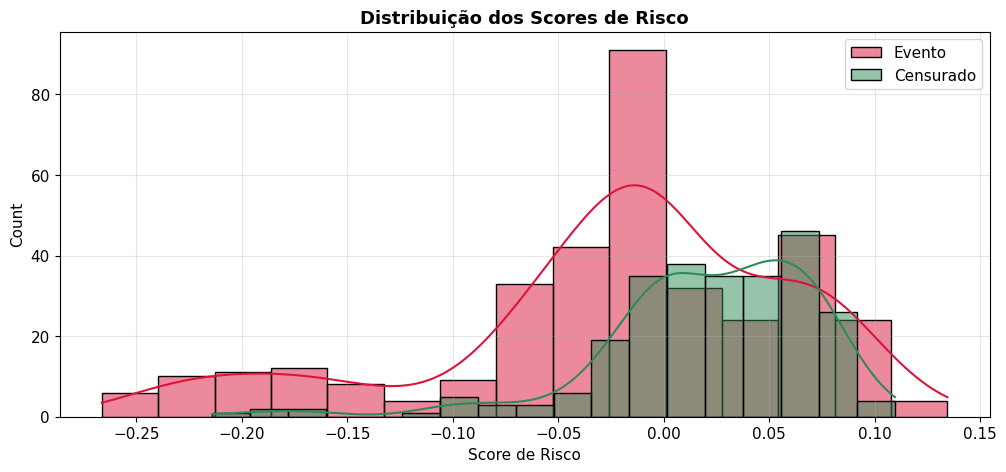

In [26]:
risk_scores = gbs.predict(X_test_s)
c_idx, concordant, discordant, _, _ = concordance_index_censored(y_test['evento'], y_test['duracao'], risk_scores)
print(f'C-Index: {c_idx:.4f} | Concordantes: {concordant} | Discordantes: {discordant}')

plt.figure(figsize=(12,5))
sns.histplot(risk_scores[y_test['evento']], kde=True, color='crimson', alpha=0.5, label='Evento')
sns.histplot(risk_scores[~y_test['evento']], kde=True, color='seagreen', alpha=0.5, label='Censurado')
plt.title('Distribuição dos Scores de Risco', fontsize=13, fontweight='bold')
plt.xlabel('Score de Risco')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 9. Feature Importance

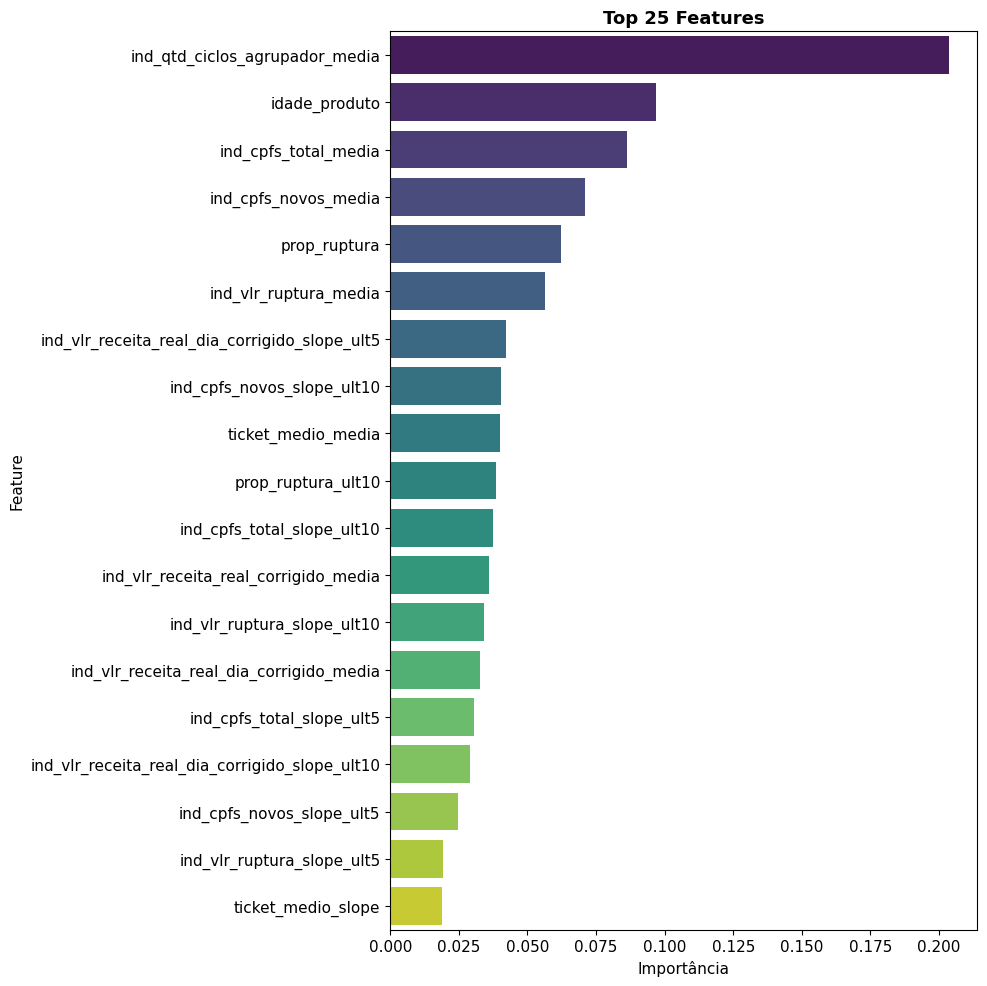

                                       Feature  Importância
                ind_qtd_ciclos_agrupador_media     0.203655
                                 idade_produto     0.096779
                          ind_cpfs_total_media     0.086373
                          ind_cpfs_novos_media     0.070790
                                  prop_ruptura     0.062050
                         ind_vlr_ruptura_media     0.056534
 ind_vlr_receita_real_dia_corrigido_slope_ult5     0.042171
                    ind_cpfs_novos_slope_ult10     0.040260
                            ticket_medio_media     0.040113
                            prop_ruptura_ult10     0.038685
                    ind_cpfs_total_slope_ult10     0.037606
          ind_vlr_receita_real_corrigido_media     0.035813
                   ind_vlr_ruptura_slope_ult10     0.034123
      ind_vlr_receita_real_dia_corrigido_media     0.032874
                     ind_cpfs_total_slope_ult5     0.030408
ind_vlr_receita_real_dia_corrigido_slope

In [27]:
imp = pd.DataFrame({'Feature': feature_cols, 'Importância': gbs.feature_importances_}).sort_values('Importância', ascending=False)
plt.figure(figsize=(10, 10))
sns.barplot(data=imp.head(25), x='Importância', y='Feature', palette='viridis')
plt.title('Top 25 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(imp.head(20).to_string(index=False))

---
## 10. Kaplan-Meier

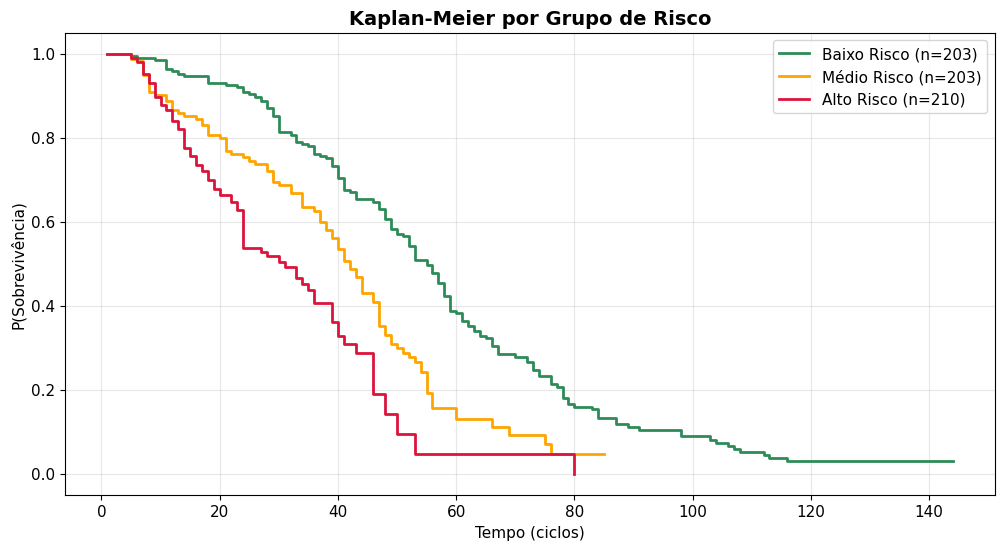

In [28]:
tercis = np.percentile(risk_scores, [33, 66])
grupos = np.digitize(risk_scores, tercis)
plt.figure(figsize=(12, 6))
for g, (label, cor) in enumerate(zip(['Baixo','Médio','Alto'],['seagreen','orange','crimson'])):
    mask = grupos == g
    if mask.sum() > 0:
        t, s = kaplan_meier_estimator(y_test['evento'][mask], y_test['duracao'][mask])
        plt.step(t, s, where='post', lw=2, color=cor, label=f'{label} Risco (n={mask.sum()})')
plt.title('Kaplan-Meier por Grupo de Risco', fontsize=14, fontweight='bold')
plt.xlabel('Tempo (ciclos)')
plt.ylabel('P(Sobrevivência)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 11. Previsão Condicional (Próx. 25 Ciclos)

In [29]:
# ============================================================
# PREVISÃO CONDICIONAL: Próximos 25 ciclos A PARTIR DE AGORA
# P(T < t+25 | T > t) = 1 - S(t+25) / S(t)
# ============================================================

df_vivos = df_surv[df_surv['evento'] == False].copy()
print(f'Prevendo para {len(df_vivos)} produtos VIVOS\n')

X_vivos = df_vivos[feature_cols].values
X_vivos_s = scaler.transform(X_vivos)
surv_vivos = gbs.predict_survival_function(X_vivos_s)
risk_vivos = gbs.predict(X_vivos_s)

prob_proximos_25 = []
ciclo_declinio_list = []

for i, fn in enumerate(surv_vivos):
    t_atual = df_vivos.iloc[i]['duracao']
    t_futuro = t_atual + HORIZONTE
    s_atual = fn(min(t_atual, fn.x.max()))
    s_futuro = fn(min(t_futuro, fn.x.max()))
    prob_cond = np.clip(1 - (s_futuro / s_atual), 0, 1) if s_atual > 0 else 1.0
    prob_proximos_25.append(prob_cond)

    ciclo_decl = np.nan
    for delta in range(1, HORIZONTE + 1):
        t_check = t_atual + delta
        if t_check <= fn.x.max():
            s_check = fn(t_check)
            if s_atual > 0 and (1 - s_check/s_atual) >= 0.5:
                ciclo_decl = delta
                break
    ciclo_declinio_list.append(ciclo_decl)

df_vivos['risk_score'] = risk_vivos
df_vivos['prob_declinio_proximos_25'] = prob_proximos_25
df_vivos['ciclo_declinio_previsto'] = ciclo_declinio_list
df_vivos['previsao_declina'] = (df_vivos['prob_declinio_proximos_25'] > 0.5).astype(int)

print('='*60)
print('PREVISÃO: PRÓXIMOS 25 CICLOS (prob condicional)')
print('='*60)
print(f'\nCom previsão de declínio (>50%): {df_vivos["previsao_declina"].sum()}')
print(f'Sem previsão: {(1-df_vivos["previsao_declina"]).sum()}')
print(f'\nDistribuição da probabilidade:')
print(df_vivos['prob_declinio_proximos_25'].describe())

declina = df_vivos[df_vivos['previsao_declina']==1]
if len(declina)>0:
    print(f'\nCiclo médio de declínio: {declina["ciclo_declinio_previsto"].mean():.1f}')
    print(f'Ciclo mediano: {declina["ciclo_declinio_previsto"].median():.1f}')

Prevendo para 1045 produtos VIVOS

PREVISÃO: PRÓXIMOS 25 CICLOS (prob condicional)

Com previsão de declínio (>50%): 294
Sem previsão: 751

Distribuição da probabilidade:
count    1045.000000
mean        0.412267
std         0.120772
min         0.000000
25%         0.320888
50%         0.377726
75%         0.514789
max         0.730075
Name: prob_declinio_proximos_25, dtype: float64

Ciclo médio de declínio: 21.3
Ciclo mediano: 21.0


---
## 12. Visualizações

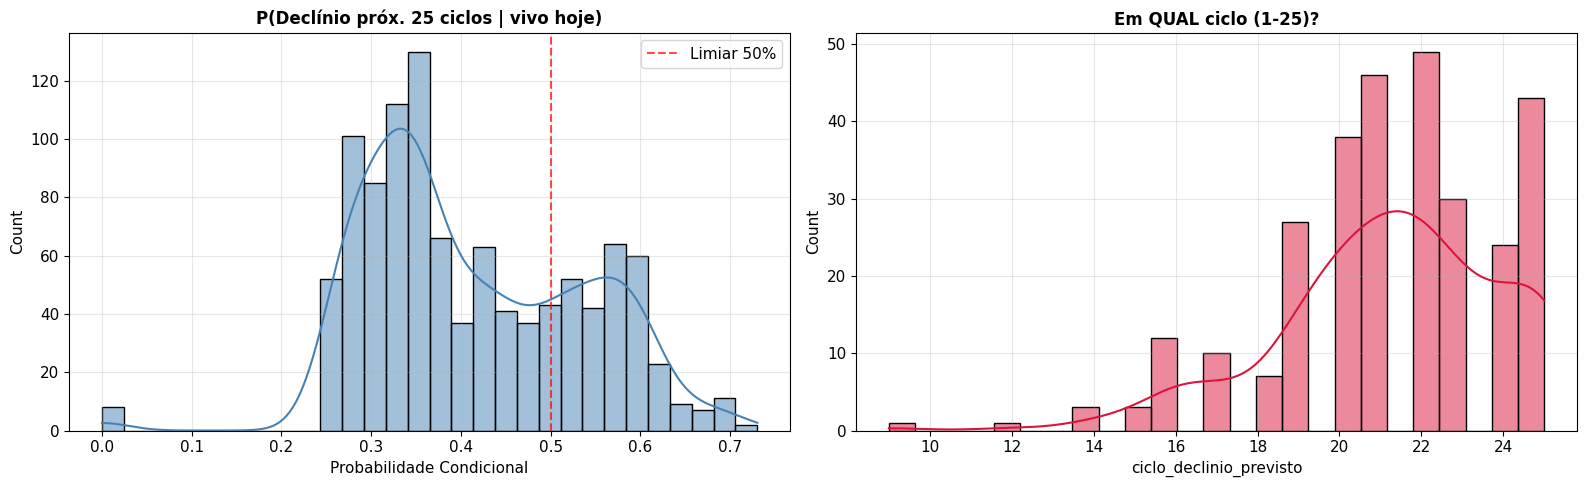

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df_vivos['prob_declinio_proximos_25'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(0.5, ls='--', color='red', alpha=0.7, label='Limiar 50%')
axes[0].set_title('P(Declínio próx. 25 ciclos | vivo hoje)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Probabilidade Condicional')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

ciclos_v = df_vivos['ciclo_declinio_previsto'].dropna()
if len(ciclos_v) > 0:
    sns.histplot(ciclos_v, bins=25, kde=True, color='crimson', ax=axes[1])
    axes[1].set_title('Em QUAL ciclo (1-25)?', fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5,0.5,'Nenhum >50%\nUse ranking',ha='center',va='center',fontsize=12)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 13. Top Risco

In [31]:
print('--- Top 20 Produtos com MAIOR risco ---')
top = df_vivos.sort_values('prob_declinio_proximos_25', ascending=False).head(20)
display(top[['sk_produto_case','duracao','prob_declinio_proximos_25','ciclo_declinio_previsto','risk_score']])

--- Top 20 Produtos com MAIOR risco ---


,sk_produto_case,duracao,prob_declinio_proximos_25,ciclo_declinio_previsto,risk_score
120,121,90.0,0.730075,14.0,-0.088353
1407,1408,81.0,0.709643,17.0,-0.013759
2128,2129,85.0,0.703768,16.0,0.004228
1568,1569,76.0,0.698953,15.0,-0.026002
1343,1344,85.0,0.697813,16.0,-0.012265
330,331,76.0,0.697007,15.0,-0.031382
1417,1418,91.0,0.695013,15.0,-0.060436
329,330,95.0,0.694485,12.0,-0.052766
242,243,84.0,0.692631,17.0,-0.037436
437,438,92.0,0.692324,14.0,-0.067854


---
## 14. Resumo

In [32]:
print('='*60)
print('  RESUMO FINAL - GBS v2 (Features Otimizadas)')
print('='*60)
print(f'\n  Modelo: Gradient Boosting Survival')
print(f'  Horizonte: {HORIZONTE} ciclos (a partir de agora)')
print(f'  Previsão: P(T<t+25 | T>t) = 1 - S(t+25)/S(t)')
print(f'  Features: {len(feature_cols)}')
print(f'  C-Index Treino: {c_train:.4f}')
print(f'  C-Index Teste:  {c_test:.4f}')
print(f'  Em risco (>50%): {df_vivos["previsao_declina"].sum()}/{len(df_vivos)}')
print('='*60)

  RESUMO FINAL - GBS v2 (Features Otimizadas)

  Modelo: Gradient Boosting Survival
  Horizonte: 25 ciclos (a partir de agora)
  Previsão: P(T<t+25 | T>t) = 1 - S(t+25)/S(t)
  Features: 19
  C-Index Treino: 0.7031
  C-Index Teste:  0.6587
  Em risco (>50%): 294/1045
